## ASV

In [2]:
import pandas as pd
import numpy as np
from tqdm import tqdm

# ======================================================
# Configuration
# ======================================================
SCORE_PATH = "/home/eoil/Interspeech2026/github/scores/RESNET.txt"

PA_DCF_CONFIGS = {
    "Pa-DCF1": dict(tar=0.97, spf=0.01, non=0.01, pa=0.01),
    "Pa-DCF2": dict(tar=0.93, spf=0.05, non=0.01, pa=0.01),
    "Pa-DCF3": dict(tar=0.93, spf=0.01, non=0.01, pa=0.05),
}

COSTS = dict(
    Cmiss=1,
    Cfa_non=10,
    Cfa_spf=10,
    Cfa_pa=10,
)

# ======================================================
# Load score file
# ======================================================
df = pd.read_csv(SCORE_PATH)

scores = df["cosine_score"].astype(float).values

is_target = (df["trial_type"] == "target").values
is_non    = (df["trial_type"] == "nontarget").values
is_spf    = (df["trial_type"] == "spoof").values       # LA spoof
is_pa     = (df["trial_type"] == "spoof_pa").values    # PA spoof

# ======================================================
# Threshold sweep
# ======================================================
thresholds = np.sort(np.unique(scores))

P_miss = []
P_fa_non = []
P_fa_spf = []
P_fa_pa  = []

for t in tqdm(thresholds, desc="Sweeping thresholds"):
    accept = scores >= t
    P_miss.append(np.mean(~accept[is_target]))
    P_fa_non.append(np.mean(accept[is_non]) if is_non.sum() > 0 else 0.0)
    P_fa_spf.append(np.mean(accept[is_spf]) if is_spf.sum() > 0 else 0.0)
    P_fa_pa.append(np.mean(accept[is_pa])  if is_pa.sum()  > 0 else 0.0)

P_miss   = np.array(P_miss)
P_fa_non = np.array(P_fa_non)
P_fa_spf = np.array(P_fa_spf)
P_fa_pa  = np.array(P_fa_pa)

# ======================================================
# EER utility
# ======================================================
def compute_eer(scores, pos_mask, neg_mask, thresholds):
    """
    pos_mask: True for positive class (target)
    neg_mask: True for negative class
    """
    Pmiss = []
    Pfa = []
    for t in thresholds:
        accept = scores >= t
        Pmiss.append(np.mean(~accept[pos_mask]))
        Pfa.append(np.mean(accept[neg_mask]))
    Pmiss = np.array(Pmiss)
    Pfa = np.array(Pfa)

    idx = np.argmin(np.abs(Pmiss - Pfa))
    eer = 0.5 * (Pmiss[idx] + Pfa[idx]) * 100
    thr = thresholds[idx]
    return eer, thr, Pmiss, Pfa

# ======================================================
# EER computations
# ======================================================
# 1) SV-EER: target vs nontarget
sv_eer, sv_thr, _, _ = compute_eer(scores, is_target, is_non, thresholds)

# 2) SPF-EER (LA): target vs spoof (LA)
spf_la_eer, spf_la_thr, _, _ = compute_eer(scores, is_target, is_spf, thresholds)

# 3) SPF-EER (PA): target vs spoof (PA)
spf_pa_eer, spf_pa_thr, _, _ = compute_eer(scores, is_target, is_pa, thresholds)

# 4) pa-SASV-EER: target vs (non + LA + PA)
neg_mask_all = is_non | is_spf | is_pa
sasv_eer, sasv_thr, _, _ = compute_eer(scores, is_target, neg_mask_all, thresholds)

print("\n================= EER Results =================")
print(f"SV-EER (target vs nontarget)      : {sv_eer:.2f}%   (thr={sv_thr:.6f})")
print(f"SPF-EER (LA) (target vs LA spoof) : {spf_la_eer:.2f}%   (thr={spf_la_thr:.6f})")
print(f"SPF-EER (PA) (target vs PA spoof) : {spf_pa_eer:.2f}%   (thr={spf_pa_thr:.6f})")
print(f"pa-SASV-EER (target vs all others): {sasv_eer:.2f}%   (thr={sasv_thr:.6f})")
print("==============================================\n")

# ======================================================
# Normalized Pa-DCF
# ======================================================
def compute_pa_dcf(Pmiss, Pnon, Pspf, Ppa, priors):
    return (
        COSTS["Cmiss"]   * priors["tar"] * Pmiss +
        COSTS["Cfa_non"] * priors["non"] * Pnon +
        COSTS["Cfa_spf"] * priors["spf"] * Pspf +
        COSTS["Cfa_pa"]  * priors["pa"]  * Ppa
    )

print("Normalized Pa-DCF results")
for name, pri in PA_DCF_CONFIGS.items():
    pa_dcf = compute_pa_dcf(P_miss, P_fa_non, P_fa_spf, P_fa_pa, pri)

    pa_dcf_def = min(
        COSTS["Cmiss"] * pri["tar"],
        COSTS["Cfa_non"] * pri["non"]
        + COSTS["Cfa_spf"] * pri["spf"]
        + COSTS["Cfa_pa"]  * pri["pa"]
    )

    pa_dcf_norm = pa_dcf / pa_dcf_def
    idx = np.argmin(pa_dcf_norm)

    print(
        f"{name}: "
        f"min Pa-DCF_norm = {pa_dcf_norm[idx]:.4f} "
        f"(thr={thresholds[idx]:.6f})"
    )

# ======================================================
# a-DCF (PA treated as spoof)
# ======================================================
A_DCF_CONFIGS = {
    "a-DCF1": dict(tar=0.98, spf=0.01, non=0.01),
}

A_COSTS = dict(
    Cmiss=1,
    Cfa_non=10,
    Cfa_spf=10,
)

def compute_a_dcf(Pmiss, Pnon, Pspf_total, priors):
    return (
        A_COSTS["Cmiss"]   * priors["tar"] * Pmiss +
        A_COSTS["Cfa_non"] * priors["non"] * Pnon +
        A_COSTS["Cfa_spf"] * priors["spf"] * Pspf_total
    )

print("\nNormalized a-DCF results (PA treated as spoof)")
P_fa_spf_total = P_fa_spf + P_fa_pa

for name, pri in A_DCF_CONFIGS.items():
    a_dcf = compute_a_dcf(P_miss, P_fa_non, P_fa_spf_total, pri)

    a_dcf_def = min(
        A_COSTS["Cmiss"] * pri["tar"],
        A_COSTS["Cfa_non"] * pri["non"] + A_COSTS["Cfa_spf"] * pri["spf"]
    )

    a_dcf_norm = a_dcf / a_dcf_def
    idx = np.argmin(a_dcf_norm)

    print(
        f"{name}: "
        f"min a-DCF_norm = {a_dcf_norm[idx]:.4f} "
        f"(thr={thresholds[idx]:.6f})"
    )

Sweeping thresholds: 100%|██████████| 180664/180664 [02:54<00:00, 1033.87it/s]



================= EER Results =================
SV-EER (target vs nontarget)      : 0.69%   (thr=0.542072)
SPF-EER (LA) (target vs LA spoof) : 25.88%   (thr=0.710398)
SPF-EER (PA) (target vs PA spoof) : 14.00%   (thr=0.676750)
pa-SASV-EER (target vs all others): 16.13%   (thr=0.683949)

Normalized Pa-DCF results
Pa-DCF1: min Pa-DCF_norm = 0.4089 (thr=0.603442)
Pa-DCF2: min Pa-DCF_norm = 0.4273 (thr=0.660921)
Pa-DCF3: min Pa-DCF_norm = 0.3212 (thr=0.661923)

Normalized a-DCF results (PA treated as spoof)
a-DCF1: min a-DCF_norm = 0.6148 (thr=0.603442)


## Single SASV

Counts (final labels)
 target : 5370
 non    : 33327
 spf(LA): 63882
 pa     : 116640
 total  : 219219


Computing FA_all: 100%|██████████| 218457/218457 [01:07<00:00, 3229.23it/s]



🎯 pa-SASV-EER (SKA-TDNN, CM-only): 17.34%
🎚  EER threshold: 0.6587


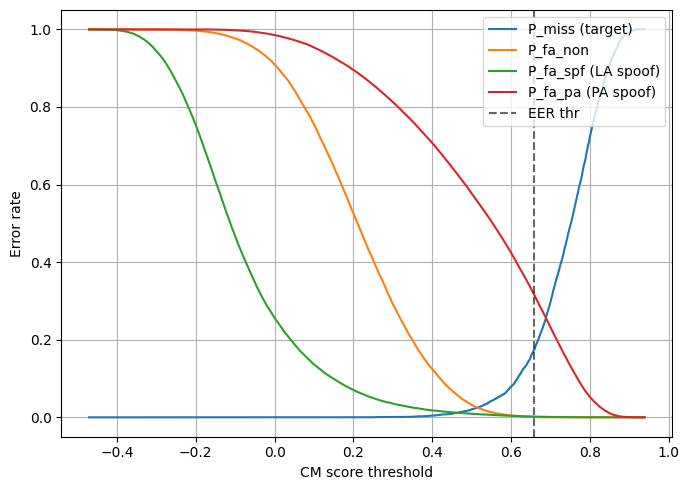


📊 Normalized pa-DCF (SKA-TDNN, CM-only)
Pa-DCF1: min pa-DCF_norm = 0.2671 (thr=0.4784)
Pa-DCF2: min pa-DCF_norm = 0.1193 (thr=0.4895)
Pa-DCF3: min pa-DCF_norm = 0.4049 (thr=0.5856)

📊 Normalized a-DCF (SKA-TDNN, CM-only)  [PA treated as spoof]
a-DCF1: min a-DCF_norm = 0.4014 (thr=0.4784)


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# ======================================================
# Path
# ======================================================
CM_SCORE_PATH = "/home/eoil/Interspeech2026/Pa-DCF/re_Score/ASVspoof19/scores_SKA_TDNN.csv"

# ======================================================
# pa-DCF configs
# ======================================================
PA_DCF_CONFIGS = {
    "Pa-DCF1": dict(tar=0.97, spf=0.01, non=0.01, pa=0.01),
    "Pa-DCF2": dict(tar=0.93, spf=0.05, non=0.01, pa=0.01),
    "Pa-DCF3": dict(tar=0.93, spf=0.01, non=0.01, pa=0.05),
}

COSTS = dict(
    Cmiss=1,
    Cfa_non=10,
    Cfa_spf=10,
    Cfa_pa=10,
)

# ======================================================
# Load CM scores
# columns:
# utt_id, enroll_id, cm_label, trial_type, cm_score
# ======================================================
df = pd.read_csv(CM_SCORE_PATH)

# 표준화
df["trial_type"] = df["trial_type"].astype(str).str.lower()
df["utt_id"]     = df["utt_id"].astype(str)
df["enroll_id"]  = df["enroll_id"].astype(str)

scores = df["cm_score"].values

# ======================================================
# 🔥 Ground-truth label 재정의 (중요)
# ======================================================
utt_upper    = df["utt_id"].str.upper()
enroll_upper = df["enroll_id"].str.upper()

# target
is_target = (df["trial_type"] == "target").values

# PA spoof:
# 1) trial_type == spoof_pa (명시적)
# 2) trial_type == nontarget + PA prefix (암묵적)
is_pa = (
    (df["trial_type"] == "spoof_pa") |
    (
        (df["trial_type"] == "nontarget") &
        (utt_upper.str.contains("PA_") | enroll_upper.str.contains("PA_"))
    )
).values

# LA spoof: spoof (단, spoof_pa 제외)
is_spf = (
    (df["trial_type"] == "spoof") &
    (~is_pa)
).values

# zero-effort nontarget
is_non = (
    (df["trial_type"] == "nontarget") &
    (~is_pa)
).values


print("Counts (final labels)")
print(" target :", is_target.sum())
print(" non    :", is_non.sum())
print(" spf(LA):", is_spf.sum())
print(" pa     :", is_pa.sum())
print(" total  :", len(df))

# ======================================================
# Threshold sweep (CM score domain)
# ======================================================
thresholds = np.sort(np.unique(scores))

P_miss, P_fa_non, P_fa_spf, P_fa_pa = [], [], [], []

for t in tqdm(thresholds, desc="Sweeping thresholds"):
    accept = scores >= t

    P_miss.append(np.mean(~accept[is_target]))
    P_fa_non.append(np.mean(accept[is_non]) if is_non.sum() else 0.0)
    P_fa_spf.append(np.mean(accept[is_spf]) if is_spf.sum() else 0.0)
    P_fa_pa.append(np.mean(accept[is_pa])  if is_pa.sum()  else 0.0)

P_miss   = np.asarray(P_miss)
P_fa_non = np.asarray(P_fa_non)
P_fa_spf = np.asarray(P_fa_spf)
P_fa_pa  = np.asarray(P_fa_pa)

# ======================================================
# pa-SASV-EER (target vs non + LA + PA)
# ======================================================
neg_mask = is_non | is_spf | is_pa
P_fa_all = []

for t in tqdm(thresholds, desc="Computing FA_all"):
    accept = scores >= t
    P_fa_all.append(np.mean(accept[neg_mask]))

P_fa_all = np.asarray(P_fa_all)

eer_idx = np.argmin(np.abs(P_miss - P_fa_all))
pa_sasv_eer = 0.5 * (P_miss[eer_idx] + P_fa_all[eer_idx]) * 100
eer_thr = thresholds[eer_idx]

print(f"\n🎯 pa-SASV-EER (SKA-TDNN, CM-only): {pa_sasv_eer:.2f}%")
print(f"🎚  EER threshold: {eer_thr:.4f}")

# ======================================================
# Plot error curves
# ======================================================
plt.figure(figsize=(7,5))
plt.plot(thresholds, P_miss,   label="P_miss (target)")
plt.plot(thresholds, P_fa_non, label="P_fa_non")
plt.plot(thresholds, P_fa_spf, label="P_fa_spf (LA spoof)")
plt.plot(thresholds, P_fa_pa,  label="P_fa_pa (PA spoof)")
plt.axvline(eer_thr, linestyle="--", color="k", alpha=0.6, label="EER thr")
plt.xlabel("CM score threshold")
plt.ylabel("Error rate")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ======================================================
# pa-DCF
# ======================================================
def compute_pa_dcf(Pmiss, Pnon, Pspf, Ppa, pri):
    return (
        COSTS["Cmiss"]   * pri["tar"] * Pmiss +
        COSTS["Cfa_non"] * pri["non"] * Pnon +
        COSTS["Cfa_spf"] * pri["spf"] * Pspf +
        COSTS["Cfa_pa"]  * pri["pa"]  * Ppa
    )

print("\n📊 Normalized pa-DCF (SKA-TDNN, CM-only)")
for name, pri in PA_DCF_CONFIGS.items():
    pa_dcf = compute_pa_dcf(P_miss, P_fa_non, P_fa_spf, P_fa_pa, pri)

    pa_dcf_def = min(
        COSTS["Cmiss"] * pri["tar"],
        COSTS["Cfa_non"] * pri["non"]
        + COSTS["Cfa_spf"] * pri["spf"]
        + COSTS["Cfa_pa"]  * pri["pa"]
    )

    pa_dcf_norm = pa_dcf / pa_dcf_def
    idx = np.argmin(pa_dcf_norm)

    print(
        f"{name}: "
        f"min pa-DCF_norm = {pa_dcf_norm[idx]:.4f} "
        f"(thr={thresholds[idx]:.4f})"
    )

# ======================================================
# a-DCF (PA를 spoof로 취급)
# ======================================================
A_DCF_CONFIGS = {
    "a-DCF1": dict(tar=0.98, spf=0.01, non=0.01),
}

A_COSTS = dict(
    Cmiss=1,
    Cfa_non=10,
    Cfa_spf=10,
)

def compute_a_dcf(Pmiss, Pnon, Pspf_total, pri):
    return (
        A_COSTS["Cmiss"]   * pri["tar"] * Pmiss +
        A_COSTS["Cfa_non"] * pri["non"] * Pnon +
        A_COSTS["Cfa_spf"] * pri["spf"] * Pspf_total
    )

print("\n📊 Normalized a-DCF (SKA-TDNN, CM-only)  [PA treated as spoof]")
P_fa_spf_total = P_fa_spf + P_fa_pa  # ✅ LA spoof + PA spoof

for name, pri in A_DCF_CONFIGS.items():
    a_dcf = compute_a_dcf(P_miss, P_fa_non, P_fa_spf_total, pri)

    a_dcf_def = min(
        A_COSTS["Cmiss"] * pri["tar"],
        A_COSTS["Cfa_non"] * pri["non"] + A_COSTS["Cfa_spf"] * pri["spf"]
    )

    a_dcf_norm = a_dcf / a_dcf_def
    idx = np.argmin(a_dcf_norm)

    print(
        f"{name}: "
        f"min a-DCF_norm = {a_dcf_norm[idx]:.4f} "
        f"(thr={thresholds[idx]:.4f})"
    )


## pa-SASV (L-P-A)

✔ merged trials (1:1): 219219


Sweeping thresholds: 100%|██████████| 45106/45106 [00:45<00:00, 999.97it/s] 



🎯 pa-SASV-EER (2-stage CM-gated)
EER        : 2.83 %
EER thr    : 0.5874


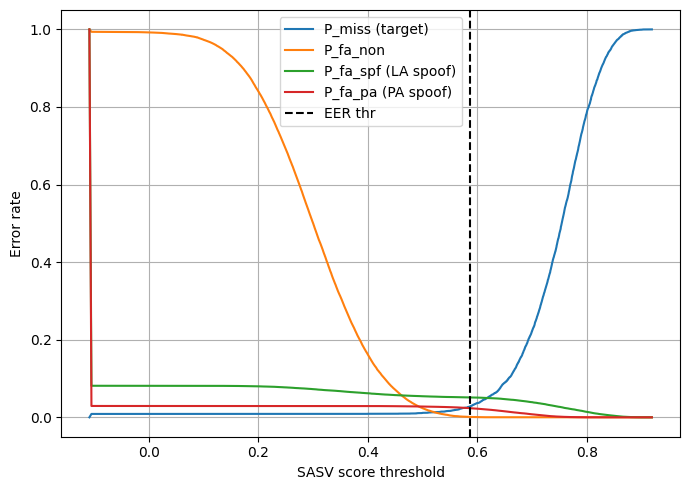


📊 Normalized pa-DCF (2-stage CM-gated)
Pa-DCF1: min pa-DCF_norm = 0.0705 (thr=0.4888)
Pa-DCF2: min pa-DCF_norm = 0.0608 (thr=0.4984)
Pa-DCF3: min pa-DCF_norm = 0.0456 (thr=0.4984)

📊 Normalized a-DCF (ASV → LA → PA gated)  [PA treated as spoof]
a-DCF1: min a-DCF_norm = 0.1063 (thr=0.4888)


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# ======================================================
# Paths
# ======================================================
ASV_SCORE_PATH = "/home/eoil/Interspeech2026/Pa-DCF/re_Score/ASVspoof19/RESNET.txt"
LA_CM_PATH     = "/home/eoil/Interspeech2026/Pa-DCF/re_Score/ASVspoof19/LAAASIST.txt"
PA_CM_PATH     = "/home/eoil/Interspeech2026/Pa-DCF/re_Score/ASVspoof19/PAAASIST_e2.txt"

# ======================================================
# Thresholds (🔥 핵심)
# ======================================================
LA_CM_THRESHOLD = -1.11
PA_CM_THRESHOLD = 0.91

# ======================================================
# Pa-DCF configs
# ======================================================
PA_DCF_CONFIGS = {
    "Pa-DCF1": dict(tar=0.97, spf=0.01, non=0.01, pa=0.01),
    "Pa-DCF2": dict(tar=0.93, spf=0.05, non=0.01, pa=0.01),
    "Pa-DCF3": dict(tar=0.93, spf=0.01, non=0.01, pa=0.05),
}

COSTS = dict(
    Cmiss=1,
    Cfa_non=10,
    Cfa_spf=10,
    Cfa_pa=10,
)

# ======================================================
# Load ASV score
# ======================================================
df_asv = pd.read_csv(ASV_SCORE_PATH)
df_asv = df_asv.rename(columns={"cosine_score": "asv_score"})

# ======================================================
# Load LA / PA CM scores
# ======================================================
df_la = pd.read_csv(LA_CM_PATH).rename(columns={"cm_score": "la_cm_score"})
df_pa = pd.read_csv(PA_CM_PATH).rename(columns={"cm_score": "pa_cm_score"})

# normalize strings
for df_ in [df_asv, df_la, df_pa]:
    for col in ["trial_type", "source"]:
        if col in df_.columns:
            df_[col] = df_[col].astype(str).str.lower()

# ======================================================
# Merge (strict 1:1)
# ======================================================
merge_keys = ["utt_id", "enroll_id", "trial_type", "source"]

df = (
    df_asv
    .merge(df_la[merge_keys + ["la_cm_score"]], on=merge_keys, how="inner")
    .merge(df_pa[merge_keys + ["pa_cm_score"]], on=merge_keys, how="inner")
)

print(f"✔ merged trials (1:1): {len(df)}")

# ======================================================
# 2-Stage CM-Gated SASV score
# ======================================================
asv_min = df["asv_score"].min()
pa_cm_min = df["pa_cm_score"].min()

# 1️⃣ LA CM gate → PA CM score
df["pa_cm_after_la"] = np.where(
    df["la_cm_score"] >= LA_CM_THRESHOLD,
    df["pa_cm_score"],
    pa_cm_min
)

# 2️⃣ PA CM gate → ASV score
df["sasv_score"] = np.where(
    df["pa_cm_after_la"] >= PA_CM_THRESHOLD,
    df["asv_score"],
    asv_min
)

scores = df["sasv_score"].values

# ======================================================
# Label masks
# ======================================================
is_target = (df["trial_type"] == "target").values
is_non    = (df["trial_type"] == "nontarget").values
is_spf    = (df["trial_type"] == "spoof").values
is_pa     = (df["trial_type"] == "spoof_pa").values

# ======================================================
# Threshold sweep
# ======================================================
thresholds = np.sort(np.unique(scores))

P_miss, P_fa_non, P_fa_spf, P_fa_pa = [], [], [], []

for t in tqdm(thresholds, desc="Sweeping thresholds"):
    accept = scores >= t

    P_miss.append(np.mean(~accept[is_target]))
    P_fa_non.append(np.mean(accept[is_non]) if is_non.sum() > 0 else 0.0)
    P_fa_spf.append(np.mean(accept[is_spf]) if is_spf.sum() > 0 else 0.0)
    P_fa_pa.append(np.mean(accept[is_pa])  if is_pa.sum()  > 0 else 0.0)

P_miss   = np.asarray(P_miss)
P_fa_non = np.asarray(P_fa_non)
P_fa_spf = np.asarray(P_fa_spf)
P_fa_pa  = np.asarray(P_fa_pa)

# ======================================================
# pa-SASV-EER (target vs rest)
# ======================================================
neg_mask = is_non | is_spf | is_pa
P_fa_all = []

for t in thresholds:
    accept = scores >= t
    P_fa_all.append(np.mean(accept[neg_mask]))

P_fa_all = np.asarray(P_fa_all)

eer_idx = np.argmin(np.abs(P_miss - P_fa_all))
sasv_eer = 0.5 * (P_miss[eer_idx] + P_fa_all[eer_idx]) * 100
eer_thr = thresholds[eer_idx]

print("\n🎯 pa-SASV-EER (2-stage CM-gated)")
print(f"EER        : {sasv_eer:.2f} %")
print(f"EER thr    : {eer_thr:.4f}")

# ======================================================
# Plot error curves
# ======================================================
plt.figure(figsize=(7, 5))
plt.plot(thresholds, P_miss, label="P_miss (target)")
plt.plot(thresholds, P_fa_non, label="P_fa_non")
plt.plot(thresholds, P_fa_spf, label="P_fa_spf (LA spoof)")
plt.plot(thresholds, P_fa_pa,  label="P_fa_pa (PA spoof)")
plt.axvline(eer_thr, color="k", linestyle="--", label="EER thr")
plt.xlabel("SASV score threshold")
plt.ylabel("Error rate")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ======================================================
# Normalized pa-DCF
# ======================================================
def compute_pa_dcf(Pmiss, Pnon, Pspf, Ppa, pri):
    return (
        COSTS["Cmiss"]   * pri["tar"] * Pmiss +
        COSTS["Cfa_non"] * pri["non"] * Pnon +
        COSTS["Cfa_spf"] * pri["spf"] * Pspf +
        COSTS["Cfa_pa"]  * pri["pa"]  * Ppa
    )

print("\n📊 Normalized pa-DCF (2-stage CM-gated)")
for name, pri in PA_DCF_CONFIGS.items():
    pa_dcf = compute_pa_dcf(P_miss, P_fa_non, P_fa_spf, P_fa_pa, pri)

    pa_dcf_def = min(
        COSTS["Cmiss"] * pri["tar"],
        COSTS["Cfa_non"] * pri["non"]
        + COSTS["Cfa_spf"] * pri["spf"]
        + COSTS["Cfa_pa"]  * pri["pa"]
    )

    pa_dcf_norm = pa_dcf / pa_dcf_def
    idx = np.argmin(pa_dcf_norm)

    print(
        f"{name}: min pa-DCF_norm = {pa_dcf_norm[idx]:.4f} "
        f"(thr={thresholds[idx]:.4f})"
    )

    # ======================================================
# Normalized a-DCF (PA를 spoof로 취급)
# ======================================================
A_DCF_CONFIGS = {
    "a-DCF1": dict(tar=0.98, spf=0.01, non=0.01),
}

A_COSTS = dict(
    Cmiss=1,
    Cfa_non=10,
    Cfa_spf=10,
)

def compute_a_dcf(Pmiss, Pnon, Pspf_total, pri):
    return (
        A_COSTS["Cmiss"]   * pri["tar"] * Pmiss +
        A_COSTS["Cfa_non"] * pri["non"] * Pnon +
        A_COSTS["Cfa_spf"] * pri["spf"] * Pspf_total
    )

print("\n📊 Normalized a-DCF (ASV → LA → PA gated)  [PA treated as spoof]")
P_fa_spf_total = P_fa_spf + P_fa_pa  # ✅ LA spoof + PA spoof 합침

for name, pri in A_DCF_CONFIGS.items():
    a_dcf = compute_a_dcf(P_miss, P_fa_non, P_fa_spf_total, pri)

    a_dcf_def = min(
        A_COSTS["Cmiss"] * pri["tar"],
        A_COSTS["Cfa_non"] * pri["non"] + A_COSTS["Cfa_spf"] * pri["spf"]
    )

    a_dcf_norm = a_dcf / a_dcf_def
    idx = np.argmin(a_dcf_norm)

    print(
        f"{name}: min a-DCF_norm = {a_dcf_norm[idx]:.4f} "
        f"(thr={thresholds[idx]:.4f})"
    )


## pa-SASV P-L-A

✔ merged trials (1:1): 219219


Sweeping thresholds: 100%|██████████| 45106/45106 [00:44<00:00, 1014.28it/s]



🎯 pa-SASV-EER (PA → LA → ASV gated)
EER        : 2.83 %
EER thr    : 0.5874


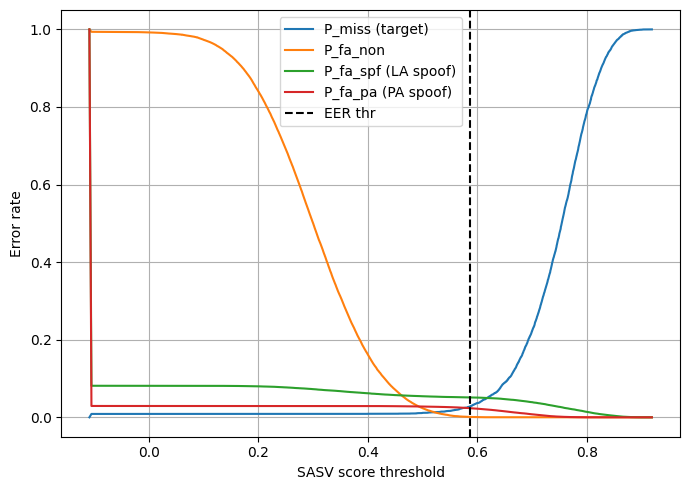


📊 Normalized pa-DCF (PA → LA → ASV gated)
Pa-DCF1: min pa-DCF_norm = 0.0705 (thr=0.4888)
Pa-DCF2: min pa-DCF_norm = 0.0608 (thr=0.4984)
Pa-DCF3: min pa-DCF_norm = 0.0456 (thr=0.4984)

📊 Normalized a-DCF (PA → LA → ASV gated)  [PA treated as spoof]
a-DCF1: min a-DCF_norm = 0.1063 (thr=0.4888)


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# ======================================================
# Paths
# ======================================================
ASV_SCORE_PATH = "/home/eoil/Interspeech2026/Pa-DCF/re_Score/ASVspoof19/RESNET.txt"
LA_CM_PATH     = "/home/eoil/Interspeech2026/Pa-DCF/re_Score/ASVspoof19/LAAASIST.txt"
PA_CM_PATH     = "/home/eoil/Interspeech2026/Pa-DCF/re_Score/ASVspoof19/PAAASIST_e2.txt"

# ======================================================
# Thresholds (🔥 핵심)
# ======================================================
PA_CM_THRESHOLD =  0.91
LA_CM_THRESHOLD = -1.11

# ======================================================
# Pa-DCF configs
# ======================================================
PA_DCF_CONFIGS = {
    "Pa-DCF1": dict(tar=0.97, spf=0.01, non=0.01, pa=0.01),
    "Pa-DCF2": dict(tar=0.93, spf=0.05, non=0.01, pa=0.01),
    "Pa-DCF3": dict(tar=0.93, spf=0.01, non=0.01, pa=0.05),
}

COSTS = dict(
    Cmiss=1,
    Cfa_non=10,
    Cfa_spf=10,
    Cfa_pa=10,
)

# ======================================================
# Load ASV score
# ======================================================
df_asv = pd.read_csv(ASV_SCORE_PATH)
df_asv = df_asv.rename(columns={"cosine_score": "asv_score"})

# ======================================================
# Load LA / PA CM scores
# ======================================================
df_la = pd.read_csv(LA_CM_PATH).rename(columns={"cm_score": "la_cm_score"})
df_pa = pd.read_csv(PA_CM_PATH).rename(columns={"cm_score": "pa_cm_score"})

# normalize strings
for df_ in [df_asv, df_la, df_pa]:
    for col in ["trial_type", "source"]:
        if col in df_.columns:
            df_[col] = df_[col].astype(str).str.lower()

# ======================================================
# Merge (strict 1:1)
# ======================================================
merge_keys = ["utt_id", "enroll_id", "trial_type", "source"]

df = (
    df_asv
    .merge(df_pa[merge_keys + ["pa_cm_score"]], on=merge_keys, how="inner")
    .merge(df_la[merge_keys + ["la_cm_score"]], on=merge_keys, how="inner")
)

print(f"✔ merged trials (1:1): {len(df)}")

# ======================================================
# PA → LA → ASV gated SASV score
# ======================================================
asv_min   = df["asv_score"].min()
la_cm_min = df["la_cm_score"].min()

# 1️⃣ PA CM gate → LA CM score
df["la_cm_after_pa"] = np.where(
    df["pa_cm_score"] >= PA_CM_THRESHOLD,
    df["la_cm_score"],
    la_cm_min
)

# 2️⃣ LA CM gate → ASV score
df["sasv_score"] = np.where(
    df["la_cm_after_pa"] >= LA_CM_THRESHOLD,
    df["asv_score"],
    asv_min
)

scores = df["sasv_score"].values

# ======================================================
# Label masks
# ======================================================
is_target = (df["trial_type"] == "target").values
is_non    = (df["trial_type"] == "nontarget").values
is_spf    = (df["trial_type"] == "spoof").values
is_pa     = (df["trial_type"] == "spoof_pa").values

# ======================================================
# Threshold sweep
# ======================================================
thresholds = np.sort(np.unique(scores))

P_miss, P_fa_non, P_fa_spf, P_fa_pa = [], [], [], []

for t in tqdm(thresholds, desc="Sweeping thresholds"):
    accept = scores >= t

    P_miss.append(np.mean(~accept[is_target]))
    P_fa_non.append(np.mean(accept[is_non]) if is_non.sum() > 0 else 0.0)
    P_fa_spf.append(np.mean(accept[is_spf]) if is_spf.sum() > 0 else 0.0)
    P_fa_pa.append(np.mean(accept[is_pa])  if is_pa.sum()  > 0 else 0.0)

P_miss   = np.asarray(P_miss)
P_fa_non = np.asarray(P_fa_non)
P_fa_spf = np.asarray(P_fa_spf)
P_fa_pa  = np.asarray(P_fa_pa)

# ======================================================
# pa-SASV-EER (target vs rest)
# ======================================================
neg_mask = is_non | is_spf | is_pa
P_fa_all = []

for t in thresholds:
    accept = scores >= t
    P_fa_all.append(np.mean(accept[neg_mask]))

P_fa_all = np.asarray(P_fa_all)

eer_idx = np.argmin(np.abs(P_miss - P_fa_all))
sasv_eer = 0.5 * (P_miss[eer_idx] + P_fa_all[eer_idx]) * 100
eer_thr = thresholds[eer_idx]

print("\n🎯 pa-SASV-EER (PA → LA → ASV gated)")
print(f"EER        : {sasv_eer:.2f} %")
print(f"EER thr    : {eer_thr:.4f}")

# ======================================================
# Plot error curves
# ======================================================
plt.figure(figsize=(7, 5))
plt.plot(thresholds, P_miss, label="P_miss (target)")
plt.plot(thresholds, P_fa_non, label="P_fa_non")
plt.plot(thresholds, P_fa_spf, label="P_fa_spf (LA spoof)")
plt.plot(thresholds, P_fa_pa,  label="P_fa_pa (PA spoof)")
plt.axvline(eer_thr, color="k", linestyle="--", label="EER thr")
plt.xlabel("SASV score threshold")
plt.ylabel("Error rate")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ======================================================
# Normalized pa-DCF
# ======================================================
def compute_pa_dcf(Pmiss, Pnon, Pspf, Ppa, pri):
    return (
        COSTS["Cmiss"]   * pri["tar"] * Pmiss +
        COSTS["Cfa_non"] * pri["non"] * Pnon +
        COSTS["Cfa_spf"] * pri["spf"] * Pspf +
        COSTS["Cfa_pa"]  * pri["pa"]  * Ppa
    )

print("\n📊 Normalized pa-DCF (PA → LA → ASV gated)")
for name, pri in PA_DCF_CONFIGS.items():
    pa_dcf = compute_pa_dcf(P_miss, P_fa_non, P_fa_spf, P_fa_pa, pri)

    pa_dcf_def = min(
        COSTS["Cmiss"] * pri["tar"],
        COSTS["Cfa_non"] * pri["non"]
        + COSTS["Cfa_spf"] * pri["spf"]
        + COSTS["Cfa_pa"]  * pri["pa"]
    )

    pa_dcf_norm = pa_dcf / pa_dcf_def
    idx = np.argmin(pa_dcf_norm)

    print(
        f"{name}: min pa-DCF_norm = {pa_dcf_norm[idx]:.4f} "
        f"(thr={thresholds[idx]:.4f})"
    )

# ======================================================
# Normalized a-DCF (PA를 spoof로 취급)
# ======================================================
A_DCF_CONFIGS = {
    "a-DCF1": dict(tar=0.98, spf=0.01, non=0.01),
}

A_COSTS = dict(
    Cmiss=1,
    Cfa_non=10,
    Cfa_spf=10,
)

def compute_a_dcf(Pmiss, Pnon, Pspf_total, pri):
    return (
        A_COSTS["Cmiss"]   * pri["tar"] * Pmiss +
        A_COSTS["Cfa_non"] * pri["non"] * Pnon +
        A_COSTS["Cfa_spf"] * pri["spf"] * Pspf_total
    )

print("\n📊 Normalized a-DCF (PA → LA → ASV gated)  [PA treated as spoof]")
P_fa_spf_total = P_fa_spf + P_fa_pa  # ✅ LA spoof + PA spoof

for name, pri in A_DCF_CONFIGS.items():
    a_dcf = compute_a_dcf(P_miss, P_fa_non, P_fa_spf_total, pri)

    a_dcf_def = min(
        A_COSTS["Cmiss"] * pri["tar"],
        A_COSTS["Cfa_non"] * pri["non"] + A_COSTS["Cfa_spf"] * pri["spf"]
    )

    a_dcf_norm = a_dcf / a_dcf_def
    idx = np.argmin(a_dcf_norm)

    print(
        f"{name}: min a-DCF_norm = {a_dcf_norm[idx]:.4f} "
        f"(thr={thresholds[idx]:.4f})"
    )


## A-L-P

✔ merged trials (1:1): 219219


Sweeping thresholds: 100%|██████████| 35542/35542 [00:34<00:00, 1032.87it/s]



🎯 pa-SASV-EER (ASV → LA → PA gated)
EER     : 2.58 %
EER thr : 1.1914


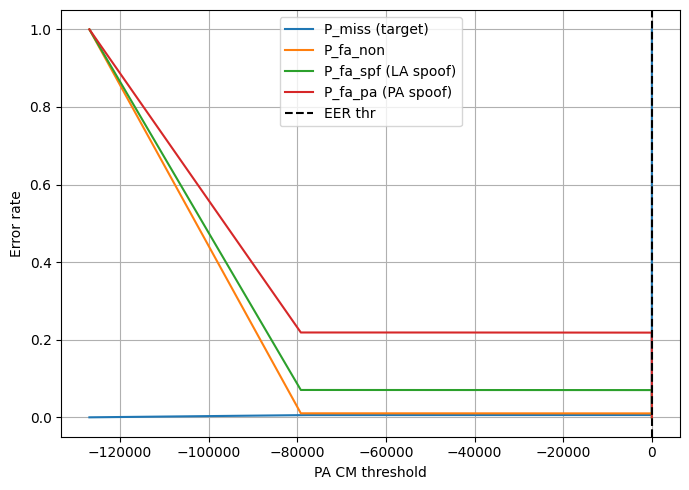


📊 Normalized pa-DCF (ASV → LA → PA gated)
Pa-DCF1: min pa-DCF_norm = 0.0570 (thr=-0.3170)
Pa-DCF2: min pa-DCF_norm = 0.0575 (thr=0.0953)
Pa-DCF3: min pa-DCF_norm = 0.0435 (thr=0.7851)

📊 Normalized a-DCF (ASV → LA → PA gated)  [PA treated as spoof]
a-DCF1: min a-DCF_norm = 0.0857 (thr=-0.3170)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# ======================================================
# Paths
# ======================================================
ASV_SCORE_PATH = "/home/eoil/Interspeech2026/Pa-DCF/re_Score/ASVspoof19/RESNET.txt"
LA_CM_PATH     = "/home/eoil/Interspeech2026/Pa-DCF/re_Score/ASVspoof19/LAAASIST.txt"
PA_CM_PATH     = "/home/eoil/Interspeech2026/Pa-DCF/re_Score/ASVspoof19/PAAASIST_e2.txt"

# ======================================================
# Thresholds (🔥 핵심)
# ======================================================
ASV_THRESHOLD  = 0.53
LA_CM_THRESHOLD = -1.11
PA_CM_THRESHOLD =  0.91

# ======================================================
# Pa-DCF configs
# ======================================================
PA_DCF_CONFIGS = {
    "Pa-DCF1": dict(tar=0.97, spf=0.01, non=0.01, pa=0.01),
    "Pa-DCF2": dict(tar=0.93, spf=0.05, non=0.01, pa=0.01),
    "Pa-DCF3": dict(tar=0.93, spf=0.01, non=0.01, pa=0.05),
}

COSTS = dict(
    Cmiss=1,
    Cfa_non=10,
    Cfa_spf=10,
    Cfa_pa=10,
)

# ======================================================
# Load scores
# ======================================================
df_asv = pd.read_csv(ASV_SCORE_PATH).rename(
    columns={"cosine_score": "asv_score"}
)
df_la = pd.read_csv(LA_CM_PATH).rename(
    columns={"cm_score": "la_cm_score"}
)
df_pa = pd.read_csv(PA_CM_PATH).rename(
    columns={"cm_score": "pa_cm_score"}
)

# normalize strings
for df_ in [df_asv, df_la, df_pa]:
    for col in ["trial_type", "source"]:
        if col in df_.columns:
            df_[col] = df_[col].astype(str).str.lower()

# ======================================================
# Merge (strict 1:1)
# ======================================================
merge_keys = ["utt_id", "enroll_id", "trial_type", "source"]

df = (
    df_asv
    .merge(df_la[merge_keys + ["la_cm_score"]], on=merge_keys, how="inner")
    .merge(df_pa[merge_keys + ["pa_cm_score"]], on=merge_keys, how="inner")
)

print(f"✔ merged trials (1:1): {len(df)}")

# ======================================================
# ASV → LA → PA gated SASV score
# ======================================================
la_min = df["la_cm_score"].min()
pa_min = df["pa_cm_score"].min()

# 1️⃣ ASV gate → LA
df["la_after_asv"] = np.where(
    df["asv_score"] >= ASV_THRESHOLD,
    df["la_cm_score"],
    la_min
)

# 2️⃣ LA gate → PA (final SASV score)
df["sasv_score"] = np.where(
    df["la_after_asv"] >= LA_CM_THRESHOLD,
    df["pa_cm_score"],
    pa_min
)

scores = df["sasv_score"].values

# ======================================================
# Label masks
# ======================================================
is_target = (df["trial_type"] == "target").values
is_non    = (df["trial_type"] == "nontarget").values
is_spf    = (df["trial_type"] == "spoof").values
is_pa     = (df["trial_type"] == "spoof_pa").values

# ======================================================
# Threshold sweep (PA score domain)
# ======================================================
thresholds = np.sort(np.unique(scores))

P_miss, P_fa_non, P_fa_spf, P_fa_pa = [], [], [], []

for t in tqdm(thresholds, desc="Sweeping thresholds"):
    accept = scores >= t

    P_miss.append(np.mean(~accept[is_target]))
    P_fa_non.append(np.mean(accept[is_non]) if is_non.sum() else 0.0)
    P_fa_spf.append(np.mean(accept[is_spf]) if is_spf.sum() else 0.0)
    P_fa_pa.append(np.mean(accept[is_pa])  if is_pa.sum()  else 0.0)

P_miss   = np.asarray(P_miss)
P_fa_non = np.asarray(P_fa_non)
P_fa_spf = np.asarray(P_fa_spf)
P_fa_pa  = np.asarray(P_fa_pa)

# ======================================================
# pa-SASV-EER
# ======================================================
neg_mask = is_non | is_spf | is_pa
P_fa_all = []

for t in thresholds:
    accept = scores >= t
    P_fa_all.append(np.mean(accept[neg_mask]))

P_fa_all = np.asarray(P_fa_all)

eer_idx = np.argmin(np.abs(P_miss - P_fa_all))
sasv_eer = 0.5 * (P_miss[eer_idx] + P_fa_all[eer_idx]) * 100
eer_thr = thresholds[eer_idx]

print("\n🎯 pa-SASV-EER (ASV → LA → PA gated)")
print(f"EER     : {sasv_eer:.2f} %")
print(f"EER thr : {eer_thr:.4f}")

# ======================================================
# Plot error curves
# ======================================================
plt.figure(figsize=(7, 5))
plt.plot(thresholds, P_miss, label="P_miss (target)")
plt.plot(thresholds, P_fa_non, label="P_fa_non")
plt.plot(thresholds, P_fa_spf, label="P_fa_spf (LA spoof)")
plt.plot(thresholds, P_fa_pa,  label="P_fa_pa (PA spoof)")
plt.axvline(eer_thr, color="k", linestyle="--", label="EER thr")
plt.xlabel("PA CM threshold")
plt.ylabel("Error rate")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ======================================================
# Normalized pa-DCF
# ======================================================
def compute_pa_dcf(Pmiss, Pnon, Pspf, Ppa, pri):
    return (
        COSTS["Cmiss"]   * pri["tar"] * Pmiss +
        COSTS["Cfa_non"] * pri["non"] * Pnon +
        COSTS["Cfa_spf"] * pri["spf"] * Pspf +
        COSTS["Cfa_pa"]  * pri["pa"]  * Ppa
    )

print("\n📊 Normalized pa-DCF (ASV → LA → PA gated)")
for name, pri in PA_DCF_CONFIGS.items():
    pa_dcf = compute_pa_dcf(P_miss, P_fa_non, P_fa_spf, P_fa_pa, pri)

    pa_dcf_def = min(
        COSTS["Cmiss"] * pri["tar"],
        COSTS["Cfa_non"] * pri["non"]
        + COSTS["Cfa_spf"] * pri["spf"]
        + COSTS["Cfa_pa"]  * pri["pa"]
    )

    pa_dcf_norm = pa_dcf / pa_dcf_def
    idx = np.argmin(pa_dcf_norm)

    print(
        f"{name}: min pa-DCF_norm = {pa_dcf_norm[idx]:.4f} "
        f"(thr={thresholds[idx]:.4f})"
    )

# ======================================================
# Normalized a-DCF (PA를 spoof로 취급)
# ======================================================
A_DCF_CONFIGS = {
    "a-DCF1": dict(tar=0.98, spf=0.01, non=0.01),
}

A_COSTS = dict(
    Cmiss=1,
    Cfa_non=10,
    Cfa_spf=10,
)

def compute_a_dcf(Pmiss, Pnon, Pspf_total, pri):
    return (
        A_COSTS["Cmiss"]   * pri["tar"] * Pmiss +
        A_COSTS["Cfa_non"] * pri["non"] * Pnon +
        A_COSTS["Cfa_spf"] * pri["spf"] * Pspf_total
    )

print("\n📊 Normalized a-DCF (ASV → LA → PA gated)  [PA treated as spoof]")
P_fa_spf_total = P_fa_spf + P_fa_pa 

for name, pri in A_DCF_CONFIGS.items():
    a_dcf = compute_a_dcf(P_miss, P_fa_non, P_fa_spf_total, pri)

    a_dcf_def = min(
        A_COSTS["Cmiss"] * pri["tar"],
        A_COSTS["Cfa_non"] * pri["non"] + A_COSTS["Cfa_spf"] * pri["spf"]
    )

    a_dcf_norm = a_dcf / a_dcf_def
    idx = np.argmin(a_dcf_norm)

    print(
        f"{name}: min a-DCF_norm = {a_dcf_norm[idx]:.4f} "
        f"(thr={thresholds[idx]:.4f})"
    )


## P-A-L

✔ merged trials (1:1): 219219


Sweeping thresholds: 100%|██████████| 39436/39436 [00:42<00:00, 931.90it/s] 



🎯 pa-SASV-EER (P → A → L gated)
EER     : 1.51 %
EER thr : 0.4948


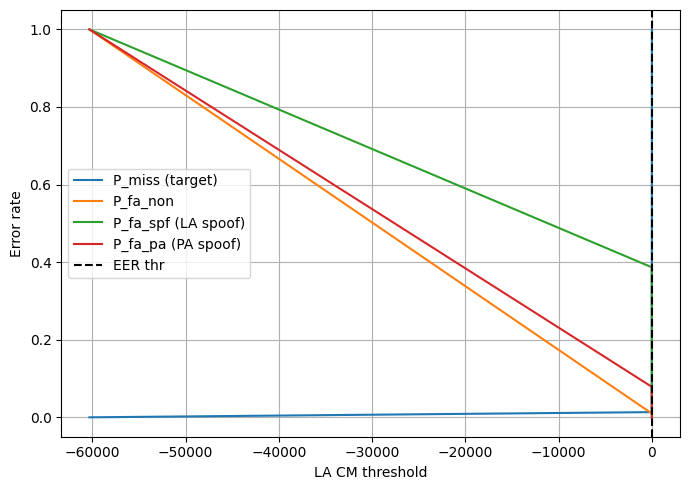


📊 Normalized pa-DCF (P → A → L gated)
Pa-DCF1: min pa-DCF_norm = 0.0613 (thr=0.6357)
Pa-DCF2: min pa-DCF_norm = 0.0277 (thr=1.4875)
Pa-DCF3: min pa-DCF_norm = 0.0368 (thr=1.5817)

📊 Normalized a-DCF (ASV → LA → PA gated)  [PA treated as spoof]
a-DCF1: min a-DCF_norm = 0.0927 (thr=0.6357)


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# ======================================================
# Paths
# ======================================================
ASV_SCORE_PATH = "/home/eoil/Interspeech2026/Pa-DCF/re_Score/ASVspoof19/RESNET.txt"
LA_CM_PATH     = "/home/eoil/Interspeech2026/Pa-DCF/re_Score/ASVspoof19/LAAASIST.txt"
PA_CM_PATH     = "/home/eoil/Interspeech2026/Pa-DCF/re_Score/ASVspoof19/PAAASIST_e2.txt"

# ======================================================
# Thresholds
# ======================================================
PA_CM_THRESHOLD = 0.91
ASV_THRESHOLD   = 0.53

# ======================================================
# Pa-DCF configs
# ======================================================
PA_DCF_CONFIGS = {
    "Pa-DCF1": dict(tar=0.97, spf=0.01, non=0.01, pa=0.01),
    "Pa-DCF2": dict(tar=0.93, spf=0.05, non=0.01, pa=0.01),
    "Pa-DCF3": dict(tar=0.93, spf=0.01, non=0.01, pa=0.05),
}

COSTS = dict(
    Cmiss=1,
    Cfa_non=10,
    Cfa_spf=10,
    Cfa_pa=10,
)

# ======================================================
# Load scores
# ======================================================
df_asv = pd.read_csv(ASV_SCORE_PATH).rename(
    columns={"cosine_score": "asv_score"}
)
df_la = pd.read_csv(LA_CM_PATH).rename(
    columns={"cm_score": "la_cm_score"}
)
df_pa = pd.read_csv(PA_CM_PATH).rename(
    columns={"cm_score": "pa_cm_score"}
)

# normalize strings
for df_ in [df_asv, df_la, df_pa]:
    for col in ["trial_type", "source"]:
        if col in df_.columns:
            df_[col] = df_[col].astype(str).str.lower()

# ======================================================
# Merge (strict 1:1)
# ======================================================
merge_keys = ["utt_id", "enroll_id", "trial_type", "source"]

df = (
    df_pa
    .merge(df_asv[merge_keys + ["asv_score"]], on=merge_keys, how="inner")
    .merge(df_la[merge_keys + ["la_cm_score"]], on=merge_keys, how="inner")
)

print(f"✔ merged trials (1:1): {len(df)}")

# ======================================================
# P → A → L gated SASV score
# ======================================================
asv_min = df["asv_score"].min()
la_min  = df["la_cm_score"].min()

# 1️⃣ PA gate → ASV
df["asv_after_pa"] = np.where(
    df["pa_cm_score"] >= PA_CM_THRESHOLD,
    df["asv_score"],
    asv_min
)

# 2️⃣ ASV gate → LA (final SASV score)
df["sasv_score"] = np.where(
    df["asv_after_pa"] >= ASV_THRESHOLD,
    df["la_cm_score"],
    la_min
)

scores = df["sasv_score"].values

# ======================================================
# Label masks
# ======================================================
is_target = (df["trial_type"] == "target").values
is_non    = (df["trial_type"] == "nontarget").values
is_spf    = (df["trial_type"] == "spoof").values
is_pa     = (df["trial_type"] == "spoof_pa").values

# ======================================================
# Threshold sweep (LA score domain)
# ======================================================
thresholds = np.sort(np.unique(scores))

P_miss, P_fa_non, P_fa_spf, P_fa_pa = [], [], [], []

for t in tqdm(thresholds, desc="Sweeping thresholds"):
    accept = scores >= t

    P_miss.append(np.mean(~accept[is_target]))
    P_fa_non.append(np.mean(accept[is_non]) if is_non.sum() else 0.0)
    P_fa_spf.append(np.mean(accept[is_spf]) if is_spf.sum() else 0.0)
    P_fa_pa.append(np.mean(accept[is_pa])  if is_pa.sum()  else 0.0)

P_miss   = np.asarray(P_miss)
P_fa_non = np.asarray(P_fa_non)
P_fa_spf = np.asarray(P_fa_spf)
P_fa_pa  = np.asarray(P_fa_pa)

# ======================================================
# pa-SASV-EER
# ======================================================
neg_mask = is_non | is_spf | is_pa
P_fa_all = []

for t in thresholds:
    accept = scores >= t
    P_fa_all.append(np.mean(accept[neg_mask]))

P_fa_all = np.asarray(P_fa_all)

eer_idx = np.argmin(np.abs(P_miss - P_fa_all))
sasv_eer = 0.5 * (P_miss[eer_idx] + P_fa_all[eer_idx]) * 100
eer_thr = thresholds[eer_idx]

print("\n🎯 pa-SASV-EER (P → A → L gated)")
print(f"EER     : {sasv_eer:.2f} %")
print(f"EER thr : {eer_thr:.4f}")

# ======================================================
# Plot error curves
# ======================================================
plt.figure(figsize=(7, 5))
plt.plot(thresholds, P_miss, label="P_miss (target)")
plt.plot(thresholds, P_fa_non, label="P_fa_non")
plt.plot(thresholds, P_fa_spf, label="P_fa_spf (LA spoof)")
plt.plot(thresholds, P_fa_pa,  label="P_fa_pa (PA spoof)")
plt.axvline(eer_thr, color="k", linestyle="--", label="EER thr")
plt.xlabel("LA CM threshold")
plt.ylabel("Error rate")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ======================================================
# Normalized pa-DCF
# ======================================================
def compute_pa_dcf(Pmiss, Pnon, Pspf, Ppa, pri):
    return (
        COSTS["Cmiss"]   * pri["tar"] * Pmiss +
        COSTS["Cfa_non"] * pri["non"] * Pnon +
        COSTS["Cfa_spf"] * pri["spf"] * Pspf +
        COSTS["Cfa_pa"]  * pri["pa"]  * Ppa
    )

print("\n📊 Normalized pa-DCF (P → A → L gated)")
for name, pri in PA_DCF_CONFIGS.items():
    pa_dcf = compute_pa_dcf(P_miss, P_fa_non, P_fa_spf, P_fa_pa, pri)

    pa_dcf_def = min(
        COSTS["Cmiss"] * pri["tar"],
        COSTS["Cfa_non"] * pri["non"]
        + COSTS["Cfa_spf"] * pri["spf"]
        + COSTS["Cfa_pa"]  * pri["pa"]
    )

    pa_dcf_norm = pa_dcf / pa_dcf_def
    idx = np.argmin(pa_dcf_norm)

    print(
        f"{name}: min pa-DCF_norm = {pa_dcf_norm[idx]:.4f} "
        f"(thr={thresholds[idx]:.4f})"
    )
# ======================================================
# Normalized a-DCF (PA를 spoof로 취급)
# ======================================================
A_DCF_CONFIGS = {
    "a-DCF1": dict(tar=0.98, spf=0.01, non=0.01),
}

A_COSTS = dict(
    Cmiss=1,
    Cfa_non=10,
    Cfa_spf=10,
)

def compute_a_dcf(Pmiss, Pnon, Pspf_total, pri):
    return (
        A_COSTS["Cmiss"]   * pri["tar"] * Pmiss +
        A_COSTS["Cfa_non"] * pri["non"] * Pnon +
        A_COSTS["Cfa_spf"] * pri["spf"] * Pspf_total
    )

print("\n📊 Normalized a-DCF (ASV → LA → PA gated)  [PA treated as spoof]")
P_fa_spf_total = P_fa_spf + P_fa_pa  # ✅ LA spoof + PA spoof 합침

for name, pri in A_DCF_CONFIGS.items():
    a_dcf = compute_a_dcf(P_miss, P_fa_non, P_fa_spf_total, pri)

    a_dcf_def = min(
        A_COSTS["Cmiss"] * pri["tar"],
        A_COSTS["Cfa_non"] * pri["non"] + A_COSTS["Cfa_spf"] * pri["spf"]
    )

    a_dcf_norm = a_dcf / a_dcf_def
    idx = np.argmin(a_dcf_norm)

    print(
        f"{name}: min a-DCF_norm = {a_dcf_norm[idx]:.4f} "
        f"(thr={thresholds[idx]:.4f})"
    )


## a p l

✔ merged trials (1:1): 219219


Sweeping thresholds: 100%|██████████| 29070/29070 [00:32<00:00, 899.31it/s]



🎯 pa-SASV-EER (A → P → L gated)
EER     : 5.51 %
EER thr : -3.0078


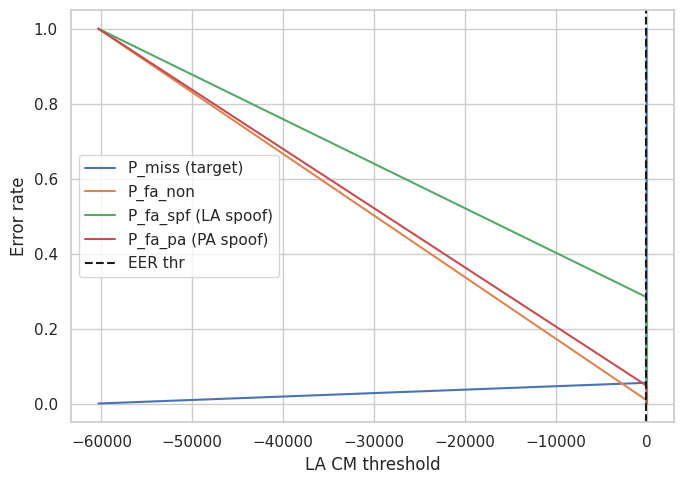


📊 Normalized pa-DCF (A → P → L gated)
Pa-DCF1: min pa-DCF_norm = 0.1935 (thr=0.7222)
Pa-DCF2: min pa-DCF_norm = 0.0815 (thr=1.4875)
Pa-DCF3: min pa-DCF_norm = 0.0881 (thr=0.7222)


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# ======================================================
# Paths
# ======================================================
ASV_SCORE_PATH = "/home/eoil/Interspeech2026/Pa-DCF/re_Score/RESNET.txt"
LA_CM_PATH     = "/home/eoil/Interspeech2026/Pa-DCF/re_Score/LAAASIST.txt"
PA_CM_PATH     = "/home/eoil/Interspeech2026/Pa-DCF/re_Score/PAAASIST.txt"

# ======================================================
# Thresholds
# ======================================================
ASV_THRESHOLD   = 0.53
PA_CM_THRESHOLD = 1.18

# ======================================================
# Pa-DCF configs
# ======================================================
PA_DCF_CONFIGS = {
    "Pa-DCF1": dict(tar=0.97, spf=0.01, non=0.01, pa=0.01),
    "Pa-DCF2": dict(tar=0.93, spf=0.05, non=0.01, pa=0.01),
    "Pa-DCF3": dict(tar=0.93, spf=0.01, non=0.01, pa=0.05),
}

COSTS = dict(
    Cmiss=1,
    Cfa_non=10,
    Cfa_spf=10,
    Cfa_pa=10,
)

# ======================================================
# Load scores
# ======================================================
df_asv = pd.read_csv(ASV_SCORE_PATH).rename(
    columns={"cosine_score": "asv_score"}
)
df_la = pd.read_csv(LA_CM_PATH).rename(
    columns={"cm_score": "la_cm_score"}
)
df_pa = pd.read_csv(PA_CM_PATH).rename(
    columns={"cm_score": "pa_cm_score"}
)

# normalize strings
for df_ in [df_asv, df_la, df_pa]:
    for col in ["trial_type", "source"]:
        if col in df_.columns:
            df_[col] = df_[col].astype(str).str.lower()

# ======================================================
# Merge (strict 1:1)
# ======================================================
merge_keys = ["utt_id", "enroll_id", "trial_type", "source"]

df = (
    df_asv
    .merge(df_pa[merge_keys + ["pa_cm_score"]], on=merge_keys, how="inner")
    .merge(df_la[merge_keys + ["la_cm_score"]], on=merge_keys, how="inner")
)

print(f"✔ merged trials (1:1): {len(df)}")

# ======================================================
# A → P → L gated SASV score
# ======================================================
pa_min = df["pa_cm_score"].min()
la_min = df["la_cm_score"].min()

# 1️⃣ ASV gate → PA
df["pa_after_asv"] = np.where(
    df["asv_score"] >= ASV_THRESHOLD,
    df["pa_cm_score"],
    pa_min
)

# 2️⃣ PA gate → LA (final SASV score)
df["sasv_score"] = np.where(
    df["pa_after_asv"] >= PA_CM_THRESHOLD,
    df["la_cm_score"],
    la_min
)

scores = df["sasv_score"].values

# ======================================================
# Label masks
# ======================================================
is_target = (df["trial_type"] == "target").values
is_non    = (df["trial_type"] == "nontarget").values
is_spf    = (df["trial_type"] == "spoof").values
is_pa     = (df["trial_type"] == "spoof_pa").values

# ======================================================
# Threshold sweep (LA score domain)
# ======================================================
thresholds = np.sort(np.unique(scores))

P_miss, P_fa_non, P_fa_spf, P_fa_pa = [], [], [], []

for t in tqdm(thresholds, desc="Sweeping thresholds"):
    accept = scores >= t

    P_miss.append(np.mean(~accept[is_target]))
    P_fa_non.append(np.mean(accept[is_non]) if is_non.sum() else 0.0)
    P_fa_spf.append(np.mean(accept[is_spf]) if is_spf.sum() else 0.0)
    P_fa_pa.append(np.mean(accept[is_pa])  if is_pa.sum()  else 0.0)

P_miss   = np.asarray(P_miss)
P_fa_non = np.asarray(P_fa_non)
P_fa_spf = np.asarray(P_fa_spf)
P_fa_pa  = np.asarray(P_fa_pa)

# ======================================================
# pa-SASV-EER
# ======================================================
neg_mask = is_non | is_spf | is_pa
P_fa_all = []

for t in thresholds:
    accept = scores >= t
    P_fa_all.append(np.mean(accept[neg_mask]))

P_fa_all = np.asarray(P_fa_all)

eer_idx = np.argmin(np.abs(P_miss - P_fa_all))
sasv_eer = 0.5 * (P_miss[eer_idx] + P_fa_all[eer_idx]) * 100
eer_thr = thresholds[eer_idx]

print("\n🎯 pa-SASV-EER (A → P → L gated)")
print(f"EER     : {sasv_eer:.2f} %")
print(f"EER thr : {eer_thr:.4f}")

# ======================================================
# Plot error curves
# ======================================================
plt.figure(figsize=(7, 5))
plt.plot(thresholds, P_miss, label="P_miss (target)")
plt.plot(thresholds, P_fa_non, label="P_fa_non")
plt.plot(thresholds, P_fa_spf, label="P_fa_spf (LA spoof)")
plt.plot(thresholds, P_fa_pa,  label="P_fa_pa (PA spoof)")
plt.axvline(eer_thr, color="k", linestyle="--", label="EER thr")
plt.xlabel("LA CM threshold")
plt.ylabel("Error rate")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ======================================================
# Normalized pa-DCF
# ======================================================
def compute_pa_dcf(Pmiss, Pnon, Pspf, Ppa, pri):
    return (
        COSTS["Cmiss"]   * pri["tar"] * Pmiss +
        COSTS["Cfa_non"] * pri["non"] * Pnon +
        COSTS["Cfa_spf"] * pri["spf"] * Pspf +
        COSTS["Cfa_pa"]  * pri["pa"]  * Ppa
    )

print("\n📊 Normalized pa-DCF (A → P → L gated)")
for name, pri in PA_DCF_CONFIGS.items():
    pa_dcf = compute_pa_dcf(P_miss, P_fa_non, P_fa_spf, P_fa_pa, pri)

    pa_dcf_def = min(
        COSTS["Cmiss"] * pri["tar"],
        COSTS["Cfa_non"] * pri["non"]
        + COSTS["Cfa_spf"] * pri["spf"]
        + COSTS["Cfa_pa"]  * pri["pa"]
    )

    pa_dcf_norm = pa_dcf / pa_dcf_def
    idx = np.argmin(pa_dcf_norm)

    print(
        f"{name}: min pa-DCF_norm = {pa_dcf_norm[idx]:.4f} "
        f"(thr={thresholds[idx]:.4f})"
    )


## pa-SASV score sum

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# ======================================================
# 설정
# ======================================================
ASV_SCORE_PATH = "/home/eoil/Interspeech2026/Pa-DCF/re_Score/ASVspoof19/RESNET.txt"
CM_LA_PATH     = "/home/eoil/Interspeech2026/Pa-DCF/re_Score/ASVspoof19/LAAASIST.txt"
CM_PA_PATH     = "/home/eoil/Interspeech2026/Pa-DCF/re_Score/ASVspoof19/PAAASIST_e2.txt"  

ALPHA    = 1.0
BETA_LA  = 1.0
BETA_PA  = 1.0

PA_DCF_CONFIGS = {
    "Pa-DCF1": dict(tar=0.97, spf=0.01, non=0.01, pa=0.01),
    "Pa-DCF2": dict(tar=0.93, spf=0.05, non=0.01, pa=0.01),
    "Pa-DCF3": dict(tar=0.93, spf=0.01, non=0.01, pa=0.05),
}

COSTS = dict(Cmiss=1, Cfa_non=10, Cfa_spf=10, Cfa_pa=10)

# ======================================================
# Utils
# ======================================================
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

# ======================================================
# Load ASV / CM (LA / PA)
# ======================================================
df_asv = pd.read_csv(ASV_SCORE_PATH).rename(
    columns={"cosine_score": "asv_score"}
)

df_cm_la = pd.read_csv(CM_LA_PATH).rename(
    columns={"cm_score": "cm_la"}
)

df_cm_pa = pd.read_csv(CM_PA_PATH).rename(
    columns={"cm_score": "cm_pa"}
)

# 표준화
for df_tmp in [df_asv, df_cm_la, df_cm_pa]:
    for col in ["trial_type", "source"]:
        df_tmp[col] = df_tmp[col].astype(str).str.lower()

# ======================================================
# 🔥 정확한 trial 기준 merge (3-way)
# ======================================================
merge_keys = ["utt_id", "enroll_id", "trial_type", "source"]

df = pd.merge(
    df_asv,
    df_cm_la[merge_keys + ["cm_la"]],
    on=merge_keys,
    how="inner",
    validate="one_to_one"
)

df = pd.merge(
    df,
    df_cm_pa[merge_keys + ["cm_pa"]],
    on=merge_keys,
    how="inner",
    validate="one_to_one"
)

print(f"✔ merged trials (ASV + LA + PA): {len(df)}")

# ======================================================
# Build SASV score (3-branch soft fusion)
# ======================================================
df["cm_la_prob"] = sigmoid(df["cm_la"])
df["cm_pa_prob"] = sigmoid(df["cm_pa"])

# ASV z-normalization
asv_mean = df["asv_score"].mean()
asv_std  = df["asv_score"].std()
df["asv_norm"] = (df["asv_score"] - asv_mean) / asv_std

df["sasv_score"] = (
    ALPHA   * df["asv_norm"] +
    BETA_LA * df["cm_la_prob"] +
    BETA_PA * df["cm_pa_prob"]
)

scores = df["sasv_score"].values

# ======================================================
# Label masks
# ======================================================
is_target = (df["trial_type"] == "target").values
is_non    = (df["trial_type"] == "nontarget").values
is_spf    = (df["trial_type"] == "spoof").values
is_pa     = (df["trial_type"] == "spoof_pa").values

# ======================================================
# Threshold sweep
# ======================================================
thresholds = np.sort(np.unique(scores))

P_miss, P_fa_non, P_fa_spf, P_fa_pa = [], [], [], []

for t in tqdm(thresholds, desc="Sweeping thresholds"):
    accept = scores >= t
    P_miss.append(np.mean(~accept[is_target]))
    P_fa_non.append(np.mean(accept[is_non]) if is_non.sum() else 0)
    P_fa_spf.append(np.mean(accept[is_spf]) if is_spf.sum() else 0)
    P_fa_pa.append(np.mean(accept[is_pa])  if is_pa.sum()  else 0)

P_miss   = np.array(P_miss)
P_fa_non = np.array(P_fa_non)
P_fa_spf = np.array(P_fa_spf)
P_fa_pa  = np.array(P_fa_pa)

# ======================================================
# pa-SASV-EER (single threshold)
# ======================================================
neg_mask = is_non | is_spf | is_pa
P_fa_all = []

for t in thresholds:
    accept = scores >= t
    P_fa_all.append(np.mean(accept[neg_mask]))

P_fa_all = np.array(P_fa_all)

eer_idx = np.argmin(np.abs(P_miss - P_fa_all))
sasv_eer = 0.5 * (P_miss[eer_idx] + P_fa_all[eer_idx]) * 100
eer_thr = thresholds[eer_idx]

print(f"\n🎯 pa-SASV-EER (ASV + LA + PA): {sasv_eer:.2f}%")
print(f"🎚  EER threshold: {eer_thr:.4f}")

# ======================================================
# pa-DCF
# ======================================================
def compute_pa_dcf(Pmiss, Pnon, Pspf, Ppa, pri):
    return (
        COSTS["Cmiss"]   * pri["tar"] * Pmiss +
        COSTS["Cfa_non"] * pri["non"] * Pnon +
        COSTS["Cfa_spf"] * pri["spf"] * Pspf +
        COSTS["Cfa_pa"]  * pri["pa"]  * Ppa
    )

print("\n📊 Normalized pa-DCF (3-branch Soft Fusion)")
for name, pri in PA_DCF_CONFIGS.items():
    pa_dcf = compute_pa_dcf(P_miss, P_fa_non, P_fa_spf, P_fa_pa, pri)
    pa_dcf_def = min(
        COSTS["Cmiss"] * pri["tar"],
        COSTS["Cfa_non"] * pri["non"]
        + COSTS["Cfa_spf"] * pri["spf"]
        + COSTS["Cfa_pa"]  * pri["pa"]
    )
    pa_dcf_norm = pa_dcf / pa_dcf_def
    idx = np.argmin(pa_dcf_norm)

    print(
        f"{name}: min pa-DCF_norm = {pa_dcf_norm[idx]:.4f} "
        f"(thr={thresholds[idx]:.4f})"
    )

    # ======================================================
# a-DCF (PA를 spoof로 취급)
# ======================================================
A_DCF_CONFIGS = {
    "a-DCF1": dict(tar=0.98, spf=0.01, non=0.01),
}

A_COSTS = dict(Cmiss=1, Cfa_non=10, Cfa_spf=10)

def compute_a_dcf(Pmiss, Pnon, Pspf_total, pri):
    return (
        A_COSTS["Cmiss"]   * pri["tar"] * Pmiss +
        A_COSTS["Cfa_non"] * pri["non"] * Pnon +
        A_COSTS["Cfa_spf"] * pri["spf"] * Pspf_total
    )

print("\n📊 Normalized a-DCF (3-branch Soft Fusion)  [PA treated as spoof]")
P_fa_spf_total = P_fa_spf + P_fa_pa  # ✅ LA spoof + PA spoof 합침

for name, pri in A_DCF_CONFIGS.items():
    a_dcf = compute_a_dcf(P_miss, P_fa_non, P_fa_spf_total, pri)

    a_dcf_def = min(
        A_COSTS["Cmiss"] * pri["tar"],
        A_COSTS["Cfa_non"] * pri["non"] + A_COSTS["Cfa_spf"] * pri["spf"]
    )

    a_dcf_norm = a_dcf / a_dcf_def
    idx = np.argmin(a_dcf_norm)

    print(
        f"{name}: min a-DCF_norm = {a_dcf_norm[idx]:.4f} "
        f"(thr={thresholds[idx]:.4f})"
    )



/home/eoil/anaconda3/envs/ad/lib/python3.8/site-packages/pandas/core/arraylike.py:358: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


✔ merged trials (ASV + LA + PA): 219219


Sweeping thresholds: 100%|██████████| 219217/219217 [03:52<00:00, 943.49it/s] 



🎯 pa-SASV-EER (ASV + LA + PA): 4.16%
🎚  EER threshold: 2.3687

📊 Normalized pa-DCF (3-branch Soft Fusion)
Pa-DCF1: min pa-DCF_norm = 0.1134 (thr=2.0543)
Pa-DCF2: min pa-DCF_norm = 0.1283 (thr=2.3365)
Pa-DCF3: min pa-DCF_norm = 0.0699 (thr=2.1873)

📊 Normalized a-DCF (3-branch Soft Fusion)  [PA treated as spoof]
a-DCF1: min a-DCF_norm = 0.1706 (thr=2.0543)


## DNN Fusion

Counts (after PA / LA split)
 target : 5370
 non    : 33327
 spf(LA): 63882
 pa     : 116640
 spoof total: 180522


Computing FA_all: 100%|██████████| 204500/204500 [00:49<00:00, 4103.24it/s]



🎯 pa-SASV-EER: 2.14%
🎚  EER threshold: 0.9165


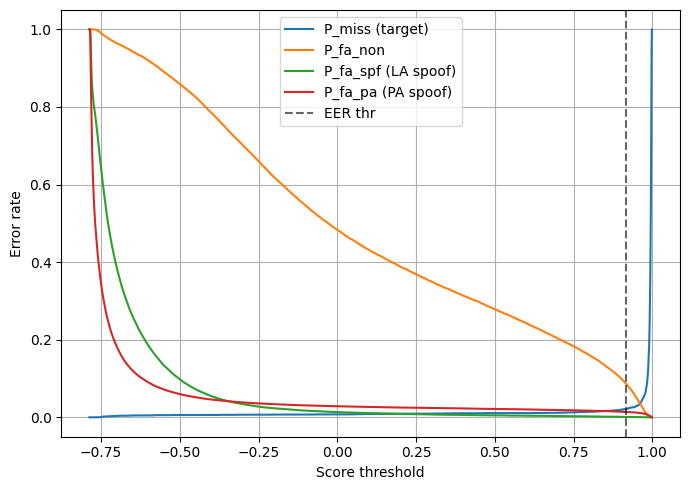


📊 Normalized pa-DCF results
Pa-DCF1: min pa-DCF_norm = 0.1007 (thr=0.8941)
Pa-DCF2: min pa-DCF_norm = 0.0428 (thr=0.8941)
Pa-DCF3: min pa-DCF_norm = 0.0505 (thr=0.8941)

📊 Normalized a-DCF results  [PA treated as spoof]
a-DCF1: min a-DCF_norm = 0.1520 (thr=0.8941)


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

# ======================================================
# Paths
# ======================================================
SCORE_TXT = "/home/eoil/sasv-joint-optimisation-2/exp_result_pa/scores/LA+PA_onlyspf_scores.txt"

# ======================================================
# pa-DCF configs
# ======================================================
PA_DCF_CONFIGS = {
    "Pa-DCF1": dict(tar=0.97, spf=0.01, non=0.01, pa=0.01),
    "Pa-DCF2": dict(tar=0.93, spf=0.05, non=0.01, pa=0.01),
    "Pa-DCF3": dict(tar=0.93, spf=0.01, non=0.01, pa=0.05),
}

COSTS = dict(
    Cmiss=1,
    Cfa_non=10,
    Cfa_spf=10,
    Cfa_pa=10,
)

# ======================================================
# Load score txt
# ======================================================
rows = []

with open(SCORE_TXT, "r") as f:
    for line in f:
        if not line.strip():
            continue
        parts = line.strip().split()
        if len(parts) != 4:
            continue

        enroll, test, trial_type, score = parts
        rows.append({
            "enroll": enroll,
            "test": test,
            "trial_type": trial_type,
            "score": float(score)
        })

df = pd.DataFrame(rows)

# ======================================================
# Label masks (🔥 PA / LA prefix 기준 핵심 수정)
# ======================================================
scores = df["score"].values

test_upper   = df["test"].str.upper()
enroll_upper = df["enroll"].str.upper()

# 기본 masks
is_target = (df["trial_type"] == "target").values

# PA spoof: nontarget이면서 PA prefix
is_pa = (
    (df["trial_type"] == "nontarget") &
    (test_upper.str.contains("PA_") | enroll_upper.str.contains("PA_"))
).values

# LA spoof: spoof으로 명시된 경우
is_spf = (df["trial_type"] == "spoof").values

# Zero-effort nontarget (PA 제외)
is_non = (
    (df["trial_type"] == "nontarget") & (~is_pa)
).values

print("Counts (after PA / LA split)")
print(" target :", is_target.sum())
print(" non    :", is_non.sum())
print(" spf(LA):", is_spf.sum())
print(" pa     :", is_pa.sum())
print(" spoof total:", is_spf.sum() + is_pa.sum())

# ======================================================
# Threshold sweep
# ======================================================
thresholds = np.sort(np.unique(scores))

P_miss = []
P_fa_non = []
P_fa_spf = []
P_fa_pa  = []

for t in tqdm(thresholds, desc="Sweeping thresholds"):
    accept = scores >= t

    P_miss.append(np.mean(~accept[is_target]))

    P_fa_non.append(np.mean(accept[is_non]) if is_non.sum() > 0 else 0.0)
    P_fa_spf.append(np.mean(accept[is_spf]) if is_spf.sum() > 0 else 0.0)
    P_fa_pa.append(np.mean(accept[is_pa])  if is_pa.sum()  > 0 else 0.0)

P_miss   = np.array(P_miss)
P_fa_non = np.array(P_fa_non)
P_fa_spf = np.array(P_fa_spf)
P_fa_pa  = np.array(P_fa_pa)

# ======================================================
# pa-SASV-EER (target vs non + spf + pa)
# ======================================================
neg_mask = is_non | is_spf | is_pa
P_fa_all = []

for t in tqdm(thresholds, desc="Computing FA_all"):
    accept = scores >= t
    P_fa_all.append(np.mean(accept[neg_mask]))

P_fa_all = np.array(P_fa_all)

eer_idx = np.argmin(np.abs(P_miss - P_fa_all))
pa_sasv_eer = 0.5 * (P_miss[eer_idx] + P_fa_all[eer_idx]) * 100
eer_thr = thresholds[eer_idx]

print(f"\n🎯 pa-SASV-EER: {pa_sasv_eer:.2f}%")
print(f"🎚  EER threshold: {eer_thr:.4f}")

# ======================================================
# Plot error curves
# ======================================================
plt.figure(figsize=(7, 5))
plt.plot(thresholds, P_miss, label="P_miss (target)")
plt.plot(thresholds, P_fa_non, label="P_fa_non")
plt.plot(thresholds, P_fa_spf, label="P_fa_spf (LA spoof)")
plt.plot(thresholds, P_fa_pa,  label="P_fa_pa (PA spoof)")
plt.axvline(eer_thr, linestyle="--", color="k", alpha=0.6, label="EER thr")

plt.xlabel("Score threshold")
plt.ylabel("Error rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ======================================================
# pa-DCF
# ======================================================
def compute_pa_dcf(Pmiss, Pnon, Pspf, Ppa, priors):
    return (
        COSTS["Cmiss"]   * priors["tar"] * Pmiss +
        COSTS["Cfa_non"] * priors["non"] * Pnon +
        COSTS["Cfa_spf"] * priors["spf"] * Pspf +
        COSTS["Cfa_pa"]  * priors["pa"]  * Ppa
    )

print("\n📊 Normalized pa-DCF results")

for name, pri in PA_DCF_CONFIGS.items():
    pa_dcf = compute_pa_dcf(
        P_miss, P_fa_non, P_fa_spf, P_fa_pa, pri
    )

    pa_dcf_def = min(
        COSTS["Cmiss"] * pri["tar"],
        COSTS["Cfa_non"] * pri["non"]
        + COSTS["Cfa_spf"] * pri["spf"]
        + COSTS["Cfa_pa"]  * pri["pa"]
    )

    pa_dcf_norm = pa_dcf / pa_dcf_def
    idx = np.argmin(pa_dcf_norm)

    print(
        f"{name}: "
        f"min pa-DCF_norm = {pa_dcf_norm[idx]:.4f} "
        f"(thr={thresholds[idx]:.4f})"
    )

# ======================================================
# a-DCF (PA를 spoof로 취급)
# ======================================================
A_DCF_CONFIGS = {
    "a-DCF1": dict(tar=0.98, spf=0.01, non=0.01),
}

A_COSTS = dict(
    Cmiss=1,
    Cfa_non=10,
    Cfa_spf=10,
)

def compute_a_dcf(Pmiss, Pnon, Pspf_total, priors):
    return (
        A_COSTS["Cmiss"]   * priors["tar"] * Pmiss +
        A_COSTS["Cfa_non"] * priors["non"] * Pnon +
        A_COSTS["Cfa_spf"] * priors["spf"] * Pspf_total
    )

print("\n📊 Normalized a-DCF results  [PA treated as spoof]")
P_fa_spf_total = P_fa_spf + P_fa_pa  # ✅ LA spoof + PA spoof

for name, pri in A_DCF_CONFIGS.items():
    a_dcf = compute_a_dcf(P_miss, P_fa_non, P_fa_spf_total, pri)

    a_dcf_def = min(
        A_COSTS["Cmiss"] * pri["tar"],
        A_COSTS["Cfa_non"] * pri["non"] + A_COSTS["Cfa_spf"] * pri["spf"]
    )

    a_dcf_norm = a_dcf / a_dcf_def
    idx = np.argmin(a_dcf_norm)

    print(
        f"{name}: "
        f"min a-DCF_norm = {a_dcf_norm[idx]:.4f} "
        f"(thr={thresholds[idx]:.4f})"
    )
